In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
def parse_slurm_blocks(filename):
    """
    Parse a Slurm output file containing repeated blocks of:
      - one or more comment lines starting with '#'
      - optional column-label line
      - numeric data lines

    Returns
    -------
    blocks : list[np.ndarray]
        One NumPy array per data block.
    block_info : dict[int, dict]
        Metadata for each block index, including:
        - 'comments': list of comment lines (without '#')
        - 'description': joined comment text
        - 'columns': column labels
    """

    def _is_number(token):
        try:
            float(token)
            return True
        except ValueError:
            return False

    def _parse_columns_from_comments(comment_lines):
        if not comment_lines:
            return None

        last = comment_lines[-1].strip()
        if not last or "|" not in last:
            return None

        # Support both "label: col1 | col2" and header-only "col1 | col2" forms.
        if ":" in last:
            candidate = last.split(":", 1)[1].strip()
        else:
            candidate = last

        if not candidate:
            return None

        cols = [c.strip() for c in candidate.split("|") if c.strip()]
        return cols if cols else None

    def _finalize_block(comment_lines, raw_lines, block_idx, blocks, block_info):
        if not raw_lines:
            return block_idx

        # Remove empty lines inside the block
        raw_lines = [ln.strip() for ln in raw_lines if ln.strip()]
        if not raw_lines:
            return block_idx

        comment_columns = _parse_columns_from_comments(comment_lines)
        #print(comment_columns)
        if comment_columns:
            columns = comment_columns
            data_lines = raw_lines
        else:
            first_tokens = raw_lines[0].split()
            has_header = not all(_is_number(tok) for tok in first_tokens)

            if has_header:
                columns = first_tokens
                data_lines = raw_lines[1:]
            else:
                data_lines = raw_lines
                ncols = len(first_tokens)
                columns = [f"col_{i}" for i in range(ncols)]

        rows = []
        for line in data_lines:
            toks = line.split()
            row = []
            for tok in toks:
                try:
                    row.append(float(tok))
                except ValueError:
                    row.append(np.nan)
            rows.append(row)

        if rows:
            max_len = max(len(r) for r in rows)
            if max_len > len(columns):
                print(f"Warning: max row length {max_len} exceeds number of columns {len(columns)}")
                maxrow = np.argmax([len(r) for r in rows])
                print(f"Row {maxrow} with max length: {rows[maxrow]}")
            target_len = max(max_len, len(columns))
            rows = [r + [np.nan] * (target_len - len(r)) for r in rows]

            if len(columns) < target_len:
                columns = columns + [f"col_{i}" for i in range(len(columns), target_len)]

            arr = np.array(rows, dtype=float)
        else:
            arr = np.empty((0, len(columns)), dtype=float)

        blocks.append(arr)
        block_info[block_idx] = {
            "comments": [c.strip() for c in comment_lines],
            "description": " ".join(c.strip() for c in comment_lines),
            "columns": columns,
        }
        return block_idx + 1

    blocks = []
    block_info = {}

    current_comments = []
    current_data_lines = []
    block_idx = 0
    with open("frontmatter.txt", "r") as fm:
        frontmatter = fm.readlines()
    frontmatter = [line.strip() for line in frontmatter]
    with open(filename, "r") as f:
        for raw in f:
            line = raw.rstrip("\n")
            if line.strip().startswith("PE 0"):
                continue
            
            if ( current_data_lines == [] and current_comments == [] ) and not line.strip().startswith("#"):
                # Skip lines that are not part of any data block and are not comments
                print(f"Skipping line outside of any block: {line}")
                continue

            #print(f"Not skipped becuase current_data_lines: {current_data_lines}, current_comments: {current_comments}, line: {line}")
            
            if line.strip().startswith("#"):
                # Starting a new comment after data means block boundary
                if current_data_lines:
                    block_idx = _finalize_block(
                        current_comments, current_data_lines, block_idx, blocks, block_info
                    )
                    current_data_lines = []
                    current_comments = []
                current_comments.append(line.strip()[1:].strip())
            elif line.strip() == "":
                # Blank line may end a block if data already collected
                if current_data_lines:
                    block_idx = _finalize_block(
                        current_comments, current_data_lines, block_idx, blocks, block_info
                    )
                    current_data_lines = []
                    current_comments = []
            else:
                current_data_lines.append(line)

    # Final block at EOF
    if current_data_lines:
        _ = _finalize_block(current_comments, current_data_lines, block_idx, blocks, block_info)

    return blocks, block_info

blocks, info = parse_slurm_blocks("slurm-5056879.out")

Skipping line outside of any block: 
Skipping line outside of any block: The following have been reloaded with a version change:
Skipping line outside of any block:   1) PrgEnv-cray/8.6.0 => PrgEnv-cray/8.7.0
Skipping line outside of any block:   2) cce/18.0.1 => cce/21.0.0
Skipping line outside of any block:   3) cray-libsci/24.11.0 => cray-libsci/26.03.0
Skipping line outside of any block:   4) cray-mpich/8.1.31 => cray-mpich/9.1.0
Skipping line outside of any block:   5) cray-pmi/6.1.15 => cray-pmi/6.1.17
Skipping line outside of any block:   6) craype/2.7.33 => craype/2.7.36
Skipping line outside of any block:   7) darshan-runtime/3.4.6-mpi => darshan-runtime/3.4.7-mpi
Skipping line outside of any block:   8) perftools-base/24.11.0 => perftools-base/26.03.0
Skipping line outside of any block: 
Skipping line outside of any block: craype-x86-trento
Skipping line outside of any block: libfabric/2.3.1
Skipping line outside of any block: craype-network-ofi
Skipping line outside of any b

In [11]:
info

{0: {'comments': ['## run: 1000 calls to MPI_Allreduce(send,recv,1,MPI_DOUBLE,MPI_SUM,MPI_COMM_WORLD) on 75776 tasks where send is host allocated and recv is host allocated',
   '# first iteration times (us): min 1150.68 avg 1176.31 max 1192.38',
   '# times for remaining 999 iterations (us): min 29.137 avg 72.3225 max 1345.7',
   'times and ranks: iteration | min (us) | rank of min | avg (us) | max (us) | rank of max'],
  'description': '## run: 1000 calls to MPI_Allreduce(send,recv,1,MPI_DOUBLE,MPI_SUM,MPI_COMM_WORLD) on 75776 tasks where send is host allocated and recv is host allocated # first iteration times (us): min 1150.68 avg 1176.31 max 1192.38 # times for remaining 999 iterations (us): min 29.137 avg 72.3225 max 1345.7 times and ranks: iteration | min (us) | rank of min | avg (us) | max (us) | rank of max',
  'columns': ['iteration',
   'min (us)',
   'rank of min',
   'avg (us)',
   'max (us)',
   'rank of max']},
 1: {'comments': ['sorted excluding first iteration: place |

In [52]:
def plot_correlation_matrix(parse_output, dataset_number, save=False):
    """
    Plot a correlation matrix for one dataset/block from parse_slurm_blocks output.

    Parameters
    ----------
    parse_output : tuple[list[np.ndarray], dict]
        Output of parse_slurm_blocks, i.e. (blocks, info).
    dataset_number : int
        Block index to plot (0-based).
    """

    blocks, info = parse_output

    if not (0 <= dataset_number < len(blocks)):
        raise IndexError(f"dataset_number must be in [0, {len(blocks)-1}]")

    arr = blocks[dataset_number]
    cols = info.get(dataset_number, {}).get("columns", [f"col_{i}" for i in range(arr.shape[1])])

    # Ensure column count matches data width
    if len(cols) < arr.shape[1]:
        cols = cols + [f"col_{i}" for i in range(len(cols), arr.shape[1])]
    else:
        cols = cols[:arr.shape[1]]

    df = pd.DataFrame(arr, columns=cols)
    corr = df.corr(numeric_only=True)

    # I prefer triangular correlation matrices
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar=True, mask=mask)
    plt.title(f"Correlation Matrix - Dataset {dataset_number}")
    plt.tight_layout()
    if save:
        plt.savefig(f"correlation_matrix_dataset_{dataset_number}.png")
        plt.close()
    else:
        plt.show()

In [6]:
def plot_dataset_subplots(parse_output, dataset_number, comment=None, n_grid_cols=3):
    """
    Plot an overview for one dataset/block:
      1) correlation matrix
      2) one subplot per non-first column, using:
         - x-axis: first column
         - y-axis: current column

    Parameters
    ----------
    parse_output : tuple[list[np.ndarray], dict]
        Output of parse_slurm_blocks, i.e. (blocks, info).
    dataset_number : int
        Block index to plot (0-based).
    n_grid_cols : int, default=3
        Number of subplot columns in the figure grid.
    """
    blocks, info = parse_output

    if not (0 <= dataset_number < len(blocks)):
        raise IndexError(f"dataset_number must be in [0, {len(blocks)-1}]")

    arr = blocks[dataset_number]
    if arr.ndim != 2 or arr.shape[1] < 2:
        raise ValueError("Selected dataset must be 2D with at least 2 columns.")

    cols = info.get(dataset_number, {}).get("columns", [f"col_{i}" for i in range(arr.shape[1])])
    if len(cols) < arr.shape[1]:
        cols = cols + [f"col_{i}" for i in range(len(cols), arr.shape[1])]
    else:
        cols = cols[:arr.shape[1]]

    df = pd.DataFrame(arr, columns=cols)

    x_col = cols[0]
    y_indices = list(range(1, arr.shape[1]))  # every column except the first
    total_plots = 1 + len(y_indices)          # 1 for correlation matrix

    n_grid_cols = max(1, min(n_grid_cols, total_plots))
    n_grid_rows = int(np.ceil(total_plots / n_grid_cols))

    fig, axes = plt.subplots(
        n_grid_rows,
        n_grid_cols,
        figsize=(5 * n_grid_cols, 4 * n_grid_rows)
    )
    axes = np.array(axes).reshape(-1)

    # Subplot 1: correlation matrix
    corr = df.corr(numeric_only=True)
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar=True, ax=axes[0])
    axes[0].set_title(f"Correlation Matrix - Dataset {dataset_number}")

    # Remaining subplots: first column on x-axis vs each other column on y-axis
    x = df[x_col].values
    for ax, j in zip(axes[1:], y_indices):
        y_col = cols[j]
        ax.plot(x, df[y_col].values, lw=1)
        ax.set_title(f"{y_col} vs {x_col}")
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)

    # Hide any unused subplot axes
    for ax in axes[total_plots:]:
        ax.axis("off")

    plt.tight_layout()
    if comment is not None:
        plt.suptitle(comment, fontsize=8)
        plt.subplots_adjust(top=0.9)  # Adjust to make room for the suptitle if present

    #plt.show()
    fig.savefig(f"dataset_{dataset_number}_overview.png")
    plt.close(fig)

In [53]:
for i in range(len(blocks)):
    print(f"Dataset {i}")
    print(info[i]["description"])
    plot_dataset_subplots((blocks, info), i, comment="\n".join(info[i]["comments"]))
    plot_correlation_matrix((blocks, info), i, save=True)

Dataset 0
## run: 1000 calls to MPI_Allreduce(send,recv,1,MPI_DOUBLE,MPI_SUM,MPI_COMM_WORLD) on 75776 tasks where send is host allocated and recv is host allocated # first iteration times (us): min 1150.68 avg 1176.31 max 1192.38 # times for remaining 999 iterations (us): min 29.137 avg 72.3225 max 1345.7 times and ranks: iteration | min (us) | rank of min | avg (us) | max (us) | rank of max
Dataset 1
sorted excluding first iteration: place | min (us) | avg (us) | max (us)
Dataset 2
rank | min (us) | avg (us) | max (us)
Dataset 3
## run: 1000 calls to MPI_Allreduce(send,recv,1,MPI_DOUBLE,MPI_SUM,MPI_COMM_WORLD) on 75776 tasks where send is host allocated and recv is host allocated # first iteration times (us): min 51.781 avg 78.5772 max 95.381 # times for remaining 999 iterations (us): min 25.74 avg 84.0236 max 3447.09 times and ranks: iteration | min (us) | rank of min | avg (us) | max (us) | rank of max
Dataset 4
sorted excluding first iteration: place | min (us) | avg (us) | max (us

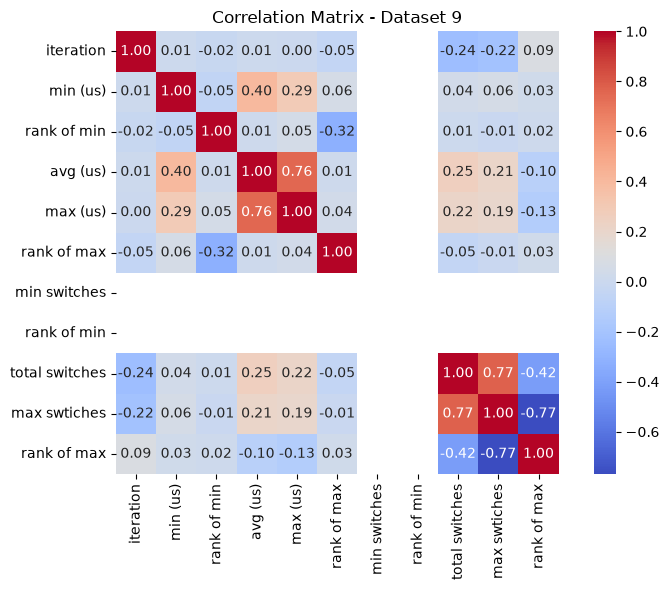

In [ ]:

plot_correlation_matrix((blocks, info), 9)

In [14]:
slow_sample = blocks[9]
cols = info[9]["columns"]

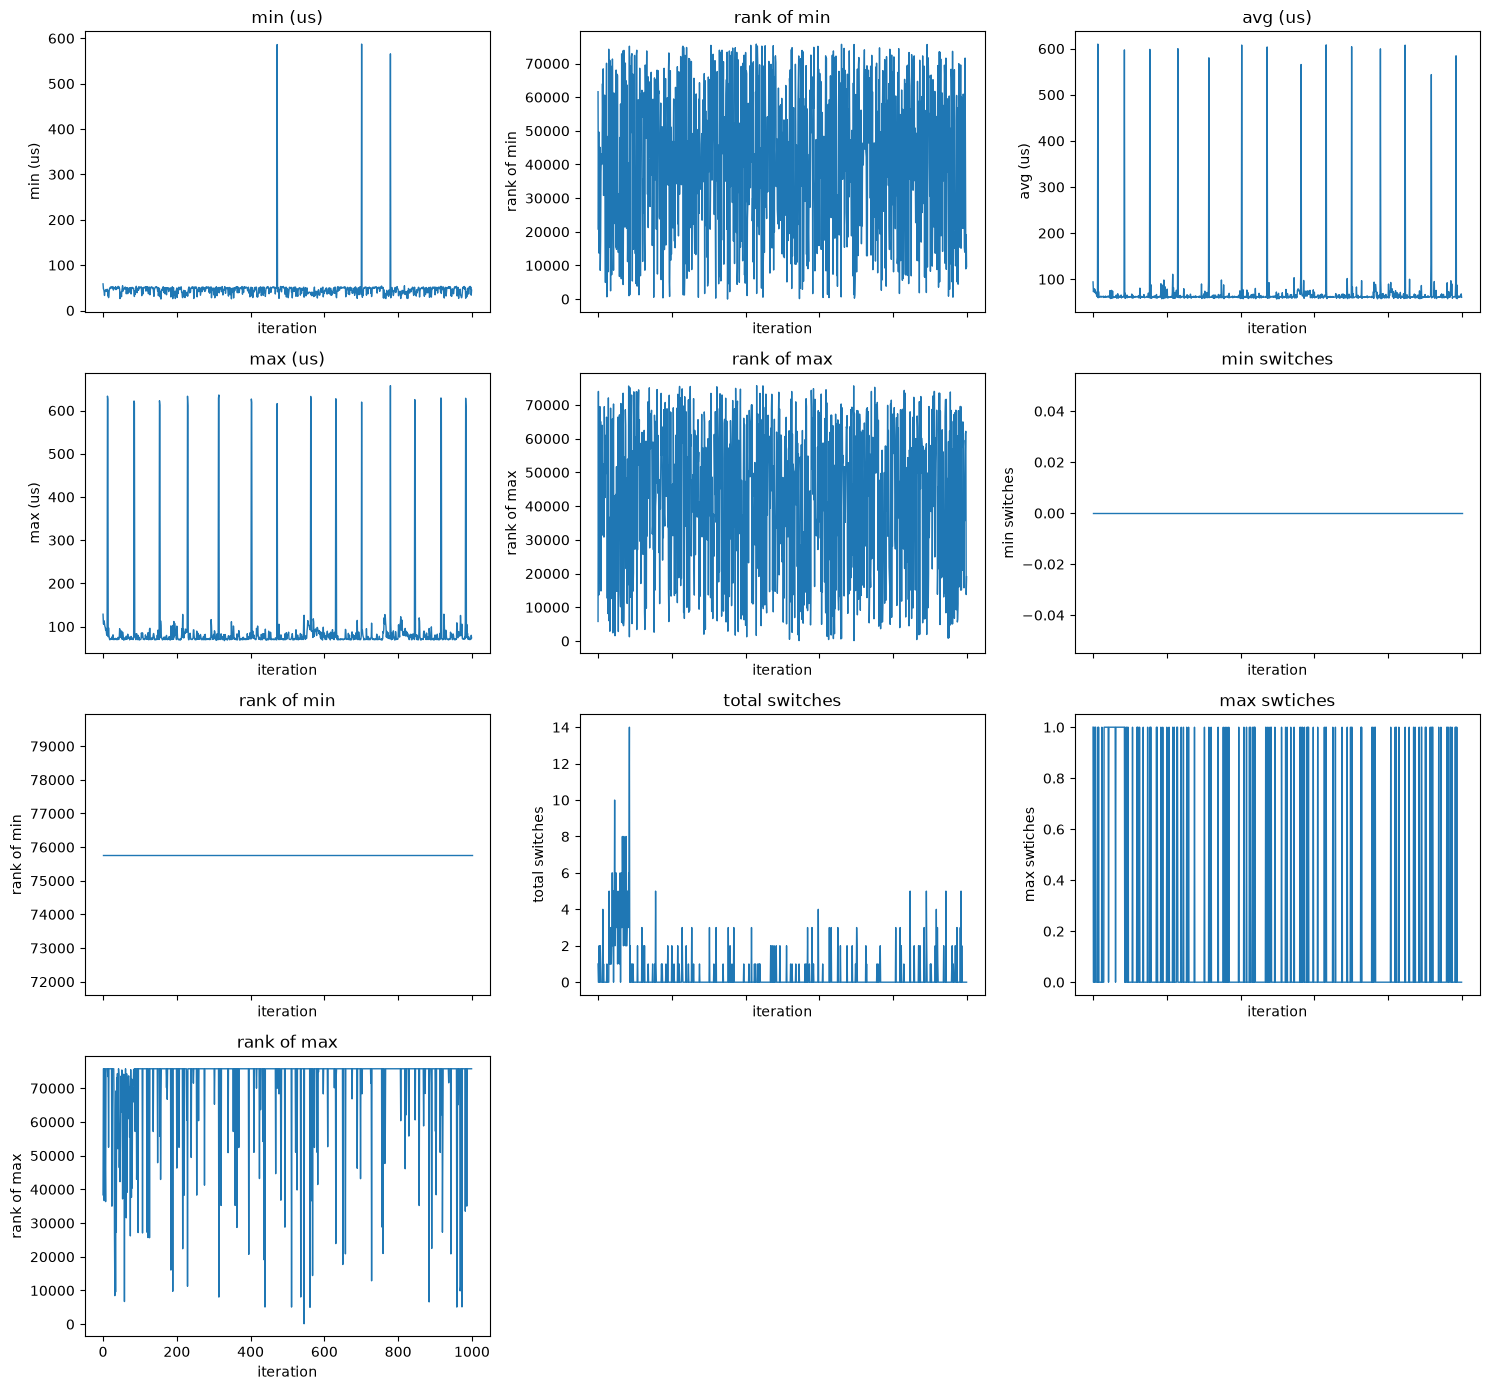

In [15]:
x = slow_sample[:, 0]

n_cols = slow_sample.shape[1]
plot_indices = list(range(1, n_cols))  # plot every column against the first column

n_plots = len(plot_indices)
n_grid_cols = 3
n_grid_rows = int(np.ceil(n_plots / n_grid_cols))

fig, axes = plt.subplots(n_grid_rows, n_grid_cols, figsize=(5 * n_grid_cols, 3.5 * n_grid_rows), sharex=True)
axes = np.array(axes).reshape(-1)

for ax, j in zip(axes, plot_indices):
    ax.plot(x, slow_sample[:, j], lw=1)
    title = cols[j] if j < len(cols) else f"col_{j}"
    ax.set_title(title)
    ax.set_xlabel(cols[0] if len(cols) > 0 else "x")
    ax.set_ylabel(title)

# hide any unused subplot axes
for ax in axes[n_plots:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [34]:
slowthreshold = 300
slowmin_mask = slow_sample[:, 1] > slowthreshold
slowavg_mask = slow_sample[:, 3] > slowthreshold
slowmax_mask = slow_sample[:, 4] > slowthreshold

In [35]:
slowmin = pd.DataFrame(slow_sample[slowmin_mask], columns=cols)
slowavg = pd.DataFrame(slow_sample[slowavg_mask], columns=cols)
slowmax = pd.DataFrame(slow_sample[slowmax_mask], columns=cols)

In [43]:
overlap_mask = slowmin_mask | slowavg_mask | slowmax_mask
merged_slow_overlap = pd.DataFrame(slow_sample[overlap_mask], columns=cols)

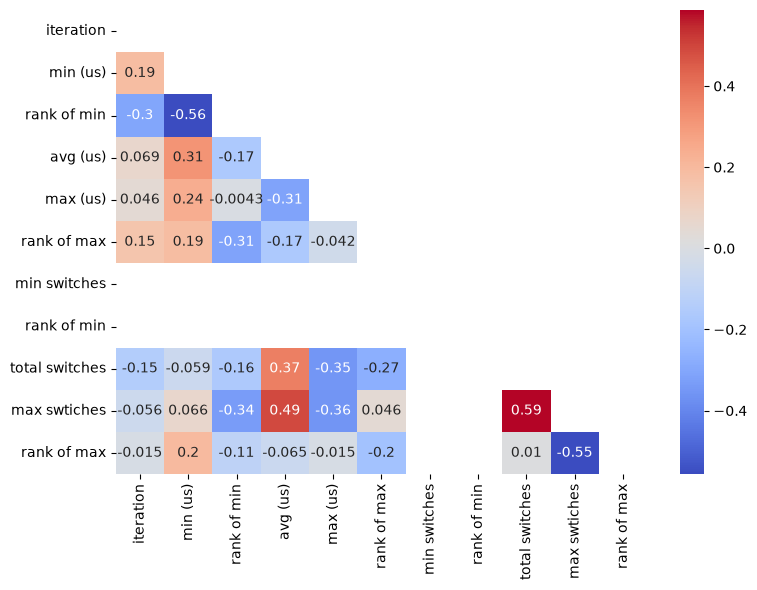

In [49]:
# Correlation plot of the merged slow intersection
# I find triangular correlation matrices easier to read

fig = plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(merged_slow_overlap.corr(), dtype=bool))
sns.heatmap(merged_slow_overlap.corr(), annot=True, cmap='coolwarm', mask=mask)
plt.tight_layout()
plt.show()

In [45]:
merged_slow_overlap

,iteration,min (us),rank of min,avg (us),max (us),rank of max,min switches,rank of min,total switches,max swtiches,rank of max
0,12.0,46.510,63975.0,61.9779,633.308,50566.0,0.0,75775.0,0.0,0.0,75775.0
1,13.0,31.912,50566.0,609.9060,626.320,31400.0,0.0,75775.0,4.0,1.0,73480.0
2,84.0,37.854,994.0,67.4799,622.072,58759.0,0.0,75775.0,6.0,1.0,71904.0
3,85.0,30.840,75142.0,597.2680,616.956,1259.0,0.0,75775.0,14.0,1.0,73552.0
4,153.0,48.825,65718.0,64.1331,622.604,66946.0,0.0,75775.0,0.0,0.0,75775.0
5,154.0,30.439,50560.0,598.3910,612.603,59951.0,0.0,75775.0,1.0,1.0,55726.0
6,229.0,31.501,74762.0,75.1249,633.083,58755.0,0.0,75775.0,1.0,1.0,11252.0
7,230.0,32.333,75143.0,599.9510,610.912,69738.0,0.0,75775.0,0.0,0.0,75775.0
8,313.0,50.656,49062.0,95.8687,628.828,37637.0,0.0,75775.0,0.0,0.0,75775.0
9,314.0,40.447,68229.0,580.0770,635.996,25131.0,0.0,75775.0,1.0,1.0,8046.0
